<a href="https://colab.research.google.com/github/Parniika2/Deep-Learning/blob/main/02_CIFAR10_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 2: Image Classification on CIFAR-10 using an Artificial Neural Network

## Objective
To build and train a feedforward Artificial Neural Network (ANN) using TensorFlow/Keras to classify images from the CIFAR-10 dataset.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.3118 - loss: 1.9291 - val_accuracy: 0.3626 - val_loss: 1.7912
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3723 - loss: 1.7733 - val_accuracy: 0.3860 - val_loss: 1.7291
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3938 - loss: 1.7099 - val_accuracy: 0.3935 - val_loss: 1.7203
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4072 - loss: 1.6690 - val_accuracy: 0.4117 - val_loss: 1.6560
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4146 - loss: 1.6496 - val_accuracy: 0.4116 - val_loss: 1.6596
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4179 - loss: 1.6328 - val_accuracy: 0.4291 - val_loss: 1.6109
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4240 - loss: 1.6207 - val_accuracy: 0.4182 - val_loss: 1.6490
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4311 - loss: 1.6047 - val_accura

Text(0.5, 1.0, 'Model Accuracy')

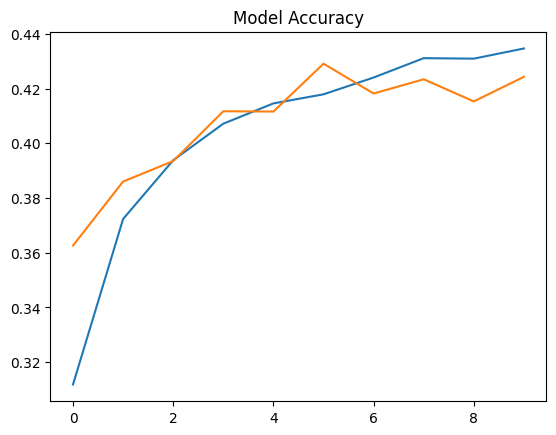

In [1]:
# Import required libraries exp 2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Build a 3-layer Neural Network
model = Sequential()

# Flatten layer (input layer)
model.add(Flatten(input_shape=(32, 32, 3)))

# Hidden layer
model.add(Dense(128, activation='relu'))

# Output layer
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")